#### Exact Matching  Evaluierung

In [44]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from latex_functions_p1 import *
from evaluate_functions_p1 import *
from plot_functions_p1 import *

### Wähle den evaluations Ordner

In [45]:
versuch_ordner = "0_shot_iter/" 
versuch_name = "0_shot_iter"

label_folder = '../input/lct_p1'
raw_lct_text_folder = '../input/lct_txt'
model_output_folder = versuch_ordner + 'model_output'
models = [folder for folder in os.listdir(model_output_folder) if os.path.isdir(os.path.join(model_output_folder, folder))]
models

['Llama-3-70B-Instruct_0_shot_v_0',
 'Llama-3-70B-Instruct_0_shot_v_1',
 'Llama-3-70B-Instruct_0_shot_v_10',
 'Llama-3-70B-Instruct_0_shot_v_11',
 'Llama-3-70B-Instruct_0_shot_v_12',
 'Llama-3-70B-Instruct_0_shot_v_13',
 'Llama-3-70B-Instruct_0_shot_v_14',
 'Llama-3-70B-Instruct_0_shot_v_15',
 'Llama-3-70B-Instruct_0_shot_v_16',
 'Llama-3-70B-Instruct_0_shot_v_17',
 'Llama-3-70B-Instruct_0_shot_v_18',
 'Llama-3-70B-Instruct_0_shot_v_19',
 'Llama-3-70B-Instruct_0_shot_v_2',
 'Llama-3-70B-Instruct_0_shot_v_3',
 'Llama-3-70B-Instruct_0_shot_v_4',
 'Llama-3-70B-Instruct_0_shot_v_5',
 'Llama-3-70B-Instruct_0_shot_v_6',
 'Llama-3-70B-Instruct_0_shot_v_7',
 'Llama-3-70B-Instruct_0_shot_v_8',
 'Llama-3-70B-Instruct_0_shot_v_9']

In [46]:
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'output')
    metrics = evaluate_models(label_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

### Missing Words PCT

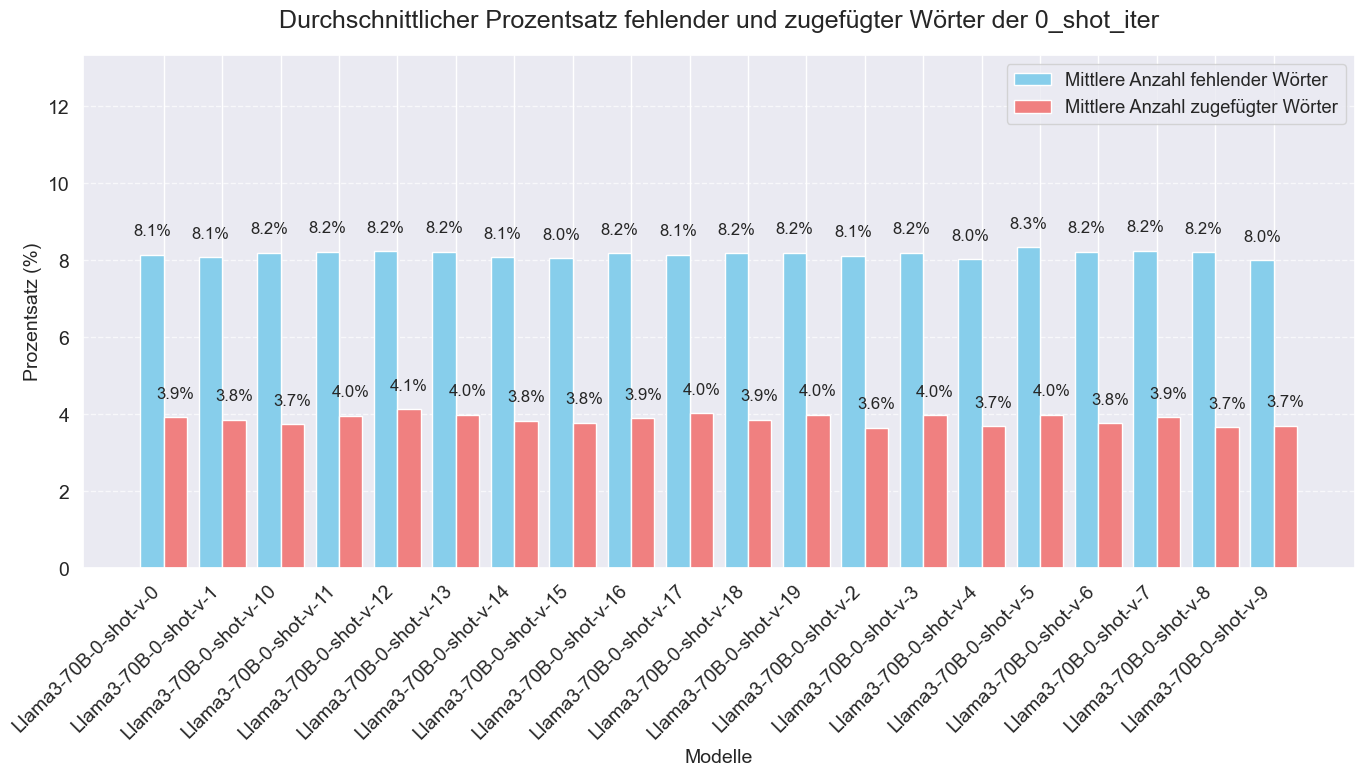

In [47]:
plot_avg_pct(all_metrics, versuch_name)

In [51]:
# n-shot P/R/F1 über alle Operatoren 
#calculate_mean_excel(all_metrics, model_names="0_shot")  


Llama-3-70B-Instruct_0_shot_v_0
Llama-3-70B-Instruct_0_shot_v_1
Llama-3-70B-Instruct_0_shot_v_10
Llama-3-70B-Instruct_0_shot_v_11
Llama-3-70B-Instruct_0_shot_v_12
Llama-3-70B-Instruct_0_shot_v_13
Llama-3-70B-Instruct_0_shot_v_14
Llama-3-70B-Instruct_0_shot_v_15
Llama-3-70B-Instruct_0_shot_v_16
Llama-3-70B-Instruct_0_shot_v_17
Llama-3-70B-Instruct_0_shot_v_18
Llama-3-70B-Instruct_0_shot_v_19
Llama-3-70B-Instruct_0_shot_v_2
Llama-3-70B-Instruct_0_shot_v_3
Llama-3-70B-Instruct_0_shot_v_4
Llama-3-70B-Instruct_0_shot_v_5
Llama-3-70B-Instruct_0_shot_v_6
Llama-3-70B-Instruct_0_shot_v_7
Llama-3-70B-Instruct_0_shot_v_8
Llama-3-70B-Instruct_0_shot_v_9
8.157951750132822
Results saved/updated in data/excel/llama70b_mean.xlsx


C:\Users\e-aut\AppData\Local\Temp\ipykernel_948\2837488523.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([existing_df, df[~df.index.isin(existing_df.index)]])


{'average_precision': 43.56768380323669,
 'average_recall': 70.58916138360584,
 'average_f1': 50.27118942184061,
 'std_precision': 0.39776196449052764,
 'std_recall': 0.8197393961965334,
 'std_f1': 0.458418942571716,
 'average_missing_percentage': 8.157951750132822,
 'average_excess_percentage': 3.8592924942541003,
 'std_missing_percentage': 0.08252020701717376,
 'std_excess_percentage': 0.1326438800193005}

In [58]:
def calculate_mean_excel(data, model_names, file_path='data/excel/llama70b_mean.xlsx'):
    n_shot_models = [model for model in data.keys()]
    operators = ['AND', 'OR', 'NOT']
    metrics = ['precision', 'recall', 'f1']

    all_metrics = {op: {metric: [] for metric in metrics} for op in operators}
    missing_percentages = []
    excess_percentages = []

    for model in n_shot_models:
        for op in operators:
            for metric in metrics:
                all_metrics[op][metric].append(data[model][op][metric])

        missing_percentages.append(data[model]['average_missing_percentage'])
        excess_percentages.append(data[model]['average_zuviel_percentage'])

    result = {}
    for op in operators:
        for metric in metrics:
            result[f'{op}_avg_{metric}'] = np.mean(all_metrics[op][metric])
            result[f'{op}_std_{metric}'] = np.std(all_metrics[op][metric])

    result['average_missing_percentage'] = np.mean(missing_percentages)
    result['average_excess_percentage'] = np.mean(excess_percentages)
    result['std_missing_percentage'] = np.std(missing_percentages)
    result['std_excess_percentage'] = np.std(excess_percentages)

    df = pd.DataFrame(result, index=[model_names])
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    if os.path.exists(file_path):
        existing_df = pd.read_excel(file_path, index_col=0)
        existing_df.update(df)
        df = pd.concat([existing_df, df[~df.index.isin(existing_df.index)]])
        print(f"Existing file updated: {file_path}")
    else:
        print(f"New file created: {file_path}")
    df.to_excel(file_path)
    print(f"Results saved in {file_path}")

    return result
calculate_mean_excel(all_metrics, model_names="0_shot")

New file created: data/excel/llama70b_mean.xlsx
Results saved in data/excel/llama70b_mean.xlsx


{'AND_avg_precision': 16.41227981383378,
 'AND_std_precision': 0.2968829211950028,
 'AND_avg_recall': 73.85802469135804,
 'AND_std_recall': 1.2841138310317717,
 'AND_avg_f1': 26.855382327823254,
 'AND_std_f1': 0.44526528570724305,
 'OR_avg_precision': 67.918026938074,
 'OR_std_precision': 0.6948806510632815,
 'OR_avg_recall': 69.45,
 'OR_std_recall': 0.8095137429346089,
 'OR_avg_f1': 68.67261235137781,
 'OR_std_f1': 0.607480510950385,
 'NOT_avg_precision': 46.3727446578023,
 'NOT_std_precision': 1.2133981696282483,
 'NOT_avg_recall': 68.45945945945947,
 'NOT_std_recall': 1.5784801892377105,
 'NOT_avg_f1': 55.28557358632075,
 'NOT_std_f1': 1.2418177908470314,
 'average_missing_percentage': 8.157951750132822,
 'average_excess_percentage': 3.8592924942541003,
 'std_missing_percentage': 0.08252020701717376,
 'std_excess_percentage': 0.1326438800193005}

### Durchschnittliche Performance über alle Operatoren [AND, OR, NOT] 

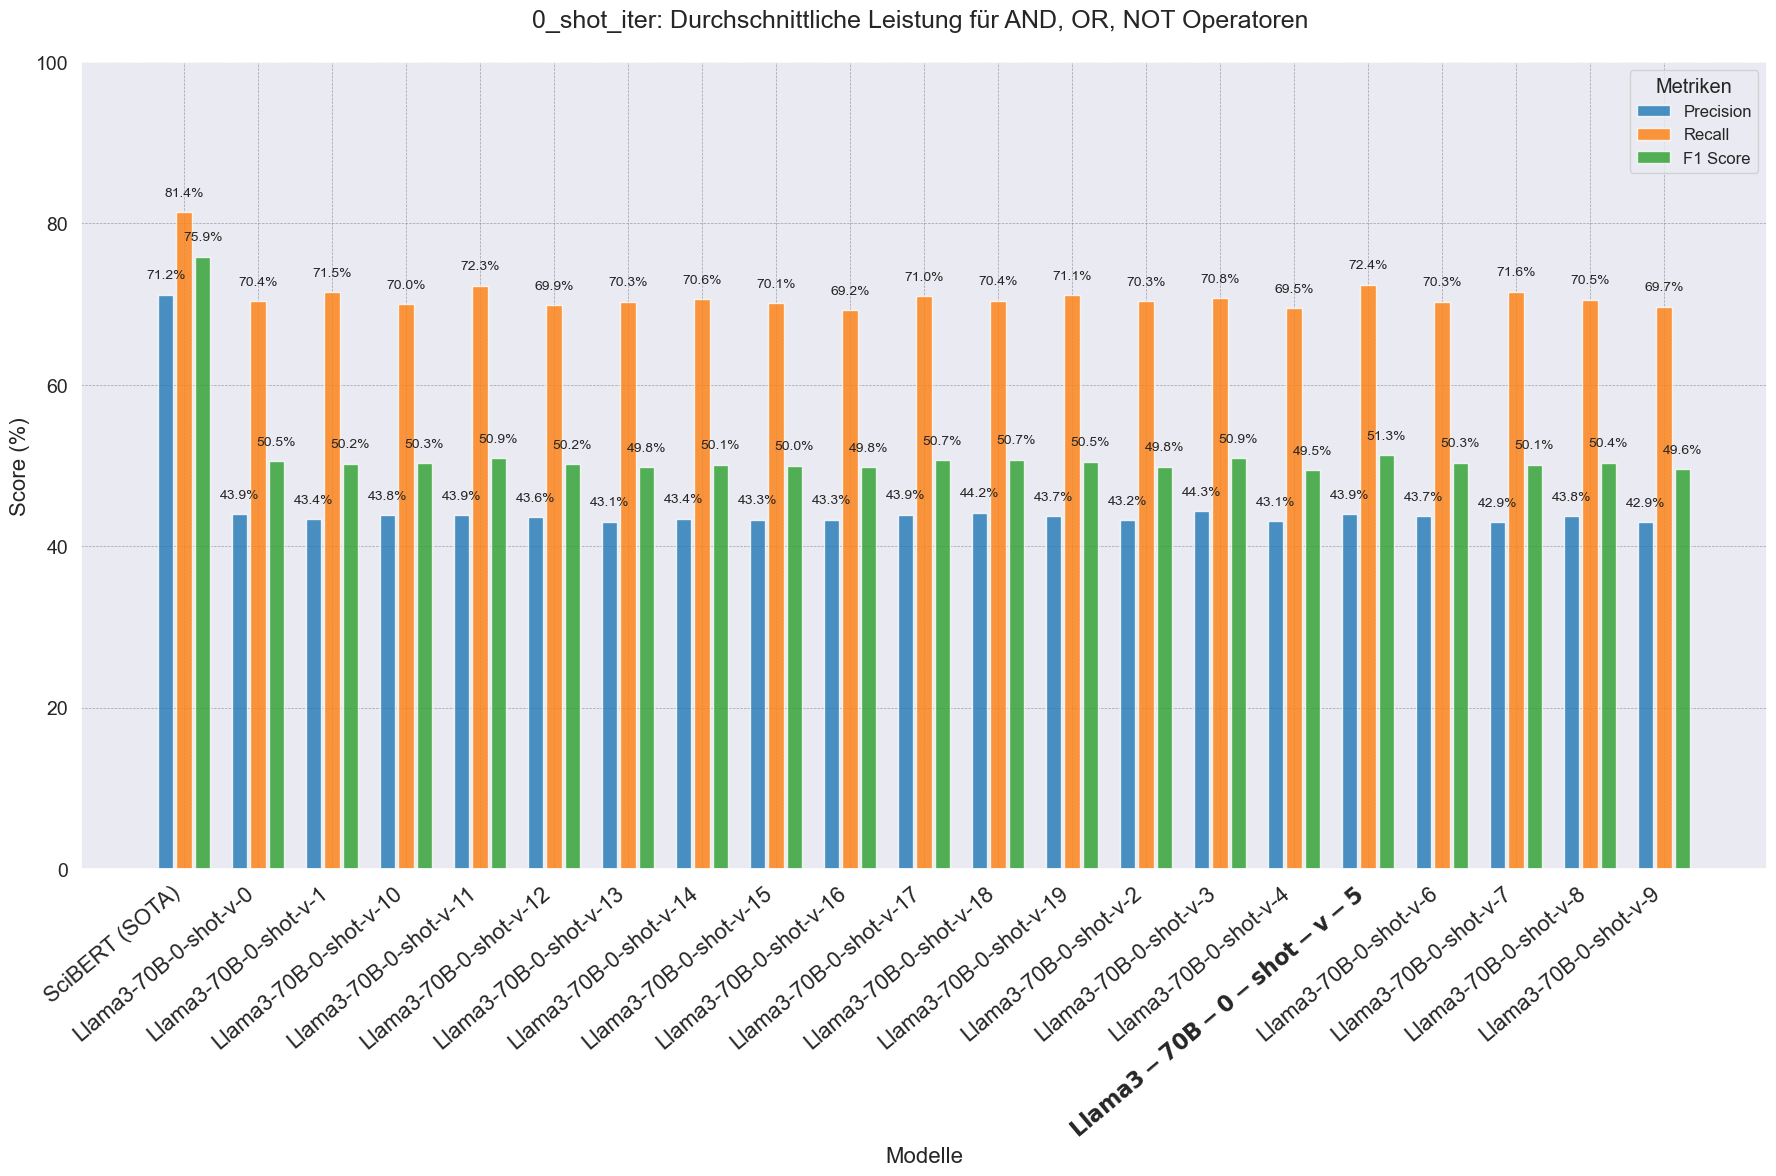

In [52]:
plot_avg_metrics(all_metrics, versuch_name)

In [59]:
def plot_f1_scores_temperatur(all_metrics):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    temperatures = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    f1_scores_70b = []
    f1_scores_llama3_5shot = []
    f1_scores_llama3_0shot = []

    for temp in temperatures:
        f1_scores_70b.append(all_metrics[f'70b_EP10_r256_temp{temp:.1f}']['average']['f1'])
        f1_scores_llama3_5shot.append(all_metrics[f'Llama-3-70B_5_shot_max_{temp:.1f}']['average']['f1'])
        f1_scores_llama3_0shot.append(all_metrics[f'Llama-3-70B-Instruct_0_shot_{temp:.1f}']['average']['f1'])

    x = np.arange(len(temperatures))
    bar_width = 0.25

    plt.figure(figsize=(16, 8))  # Größere Figur für mehr Platz
    sns.set_style("whitegrid")

    # Balken
    plt.bar(x - bar_width, f1_scores_70b, bar_width, alpha=0.8, color='#A9D0F5', label='Fine-Tuned')
    plt.bar(x, f1_scores_llama3_5shot, bar_width, alpha=0.8, color='#FFA07A', label='5-shot')
    plt.bar(x + bar_width, f1_scores_llama3_0shot, bar_width, alpha=0.8, color='#90EE90', label='0-shot')

    # Linien
    plt.plot(x - bar_width, f1_scores_70b, color='blue', linestyle='-', linewidth=2)
    plt.plot(x, f1_scores_llama3_5shot, color='red', linestyle='-', linewidth=2)
    plt.plot(x + bar_width, f1_scores_llama3_0shot, color='green', linestyle='-', linewidth=2)

    # Punkte mittig auf den Balken
    plt.scatter(x - bar_width, f1_scores_70b, color='blue', s=50, zorder=3)
    plt.scatter(x, f1_scores_llama3_5shot, color='red', s=50, zorder=3)
    plt.scatter(x + bar_width, f1_scores_llama3_0shot, color='green', s=50, zorder=3)

    plt.xlabel('Temperatur', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel('F1 Score', fontsize=14, fontweight='bold', labelpad=15)
    plt.title('Llama3 70b', fontsize=16, fontweight='bold', pad=20)

    plt.xticks(x, temperatures, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, 100)

    plt.legend(fontsize=12, loc='upper right')

    # Werte auf den Balken mit Prozentzeichen
    for i, v in enumerate(f1_scores_70b):
        plt.text(i - bar_width, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(f1_scores_llama3_5shot):
        plt.text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(f1_scores_llama3_0shot):
        plt.text(i + bar_width, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'data/pics/Temperatur.png')
    plt.show()

#plot_f1_scores_temperatur(all_metrics)

  ### Durchschnittliche Performance über alle Operatoren [AND, OR, NOT] to LATEX

In [60]:
avg_operators_latex(all_metrics, versuch_name)

'\\begin{table}[ht]\n\\centering\n\\begin{tabular}{lccc}\n\\toprule\nModel & Precision & Recall & F1 \\\\\n\\midrule\nSciBERT (SOTA) & 71.2 & \\textbf{81.4} & \\textbf{75.9} \\\\\nR-BERT + SciBERT & \\textbf{72.2} & 78.2 & 75.0 \\\\\nLlama-3-70B-Instruct-0-shot-v-0 & 43.9 & 70.4 & 50.5 \\\\\nLlama-3-70B-Instruct-0-shot-v-1 & 43.4 & 71.5 & 50.2 \\\\\nLlama-3-70B-Instruct-0-shot-v-10 & 43.8 & 70.0 & 50.3 \\\\\nLlama-3-70B-Instruct-0-shot-v-11 & 43.9 & 72.3 & 50.9 \\\\\nLlama-3-70B-Instruct-0-shot-v-12 & 43.6 & 69.9 & 50.2 \\\\\nLlama-3-70B-Instruct-0-shot-v-13 & 43.1 & 70.3 & 49.8 \\\\\nLlama-3-70B-Instruct-0-shot-v-14 & 43.4 & 70.6 & 50.1 \\\\\nLlama-3-70B-Instruct-0-shot-v-15 & 43.3 & 70.1 & 50.0 \\\\\nLlama-3-70B-Instruct-0-shot-v-16 & 43.3 & 69.2 & 49.8 \\\\\nLlama-3-70B-Instruct-0-shot-v-17 & 43.9 & 71.0 & 50.7 \\\\\nLlama-3-70B-Instruct-0-shot-v-18 & 44.2 & 70.4 & 50.7 \\\\\nLlama-3-70B-Instruct-0-shot-v-19 & 43.7 & 71.1 & 50.5 \\\\\nLlama-3-70B-Instruct-0-shot-v-2 & 43.2 & 70.3 & 

### Perfomance der einzelnen Operatoren

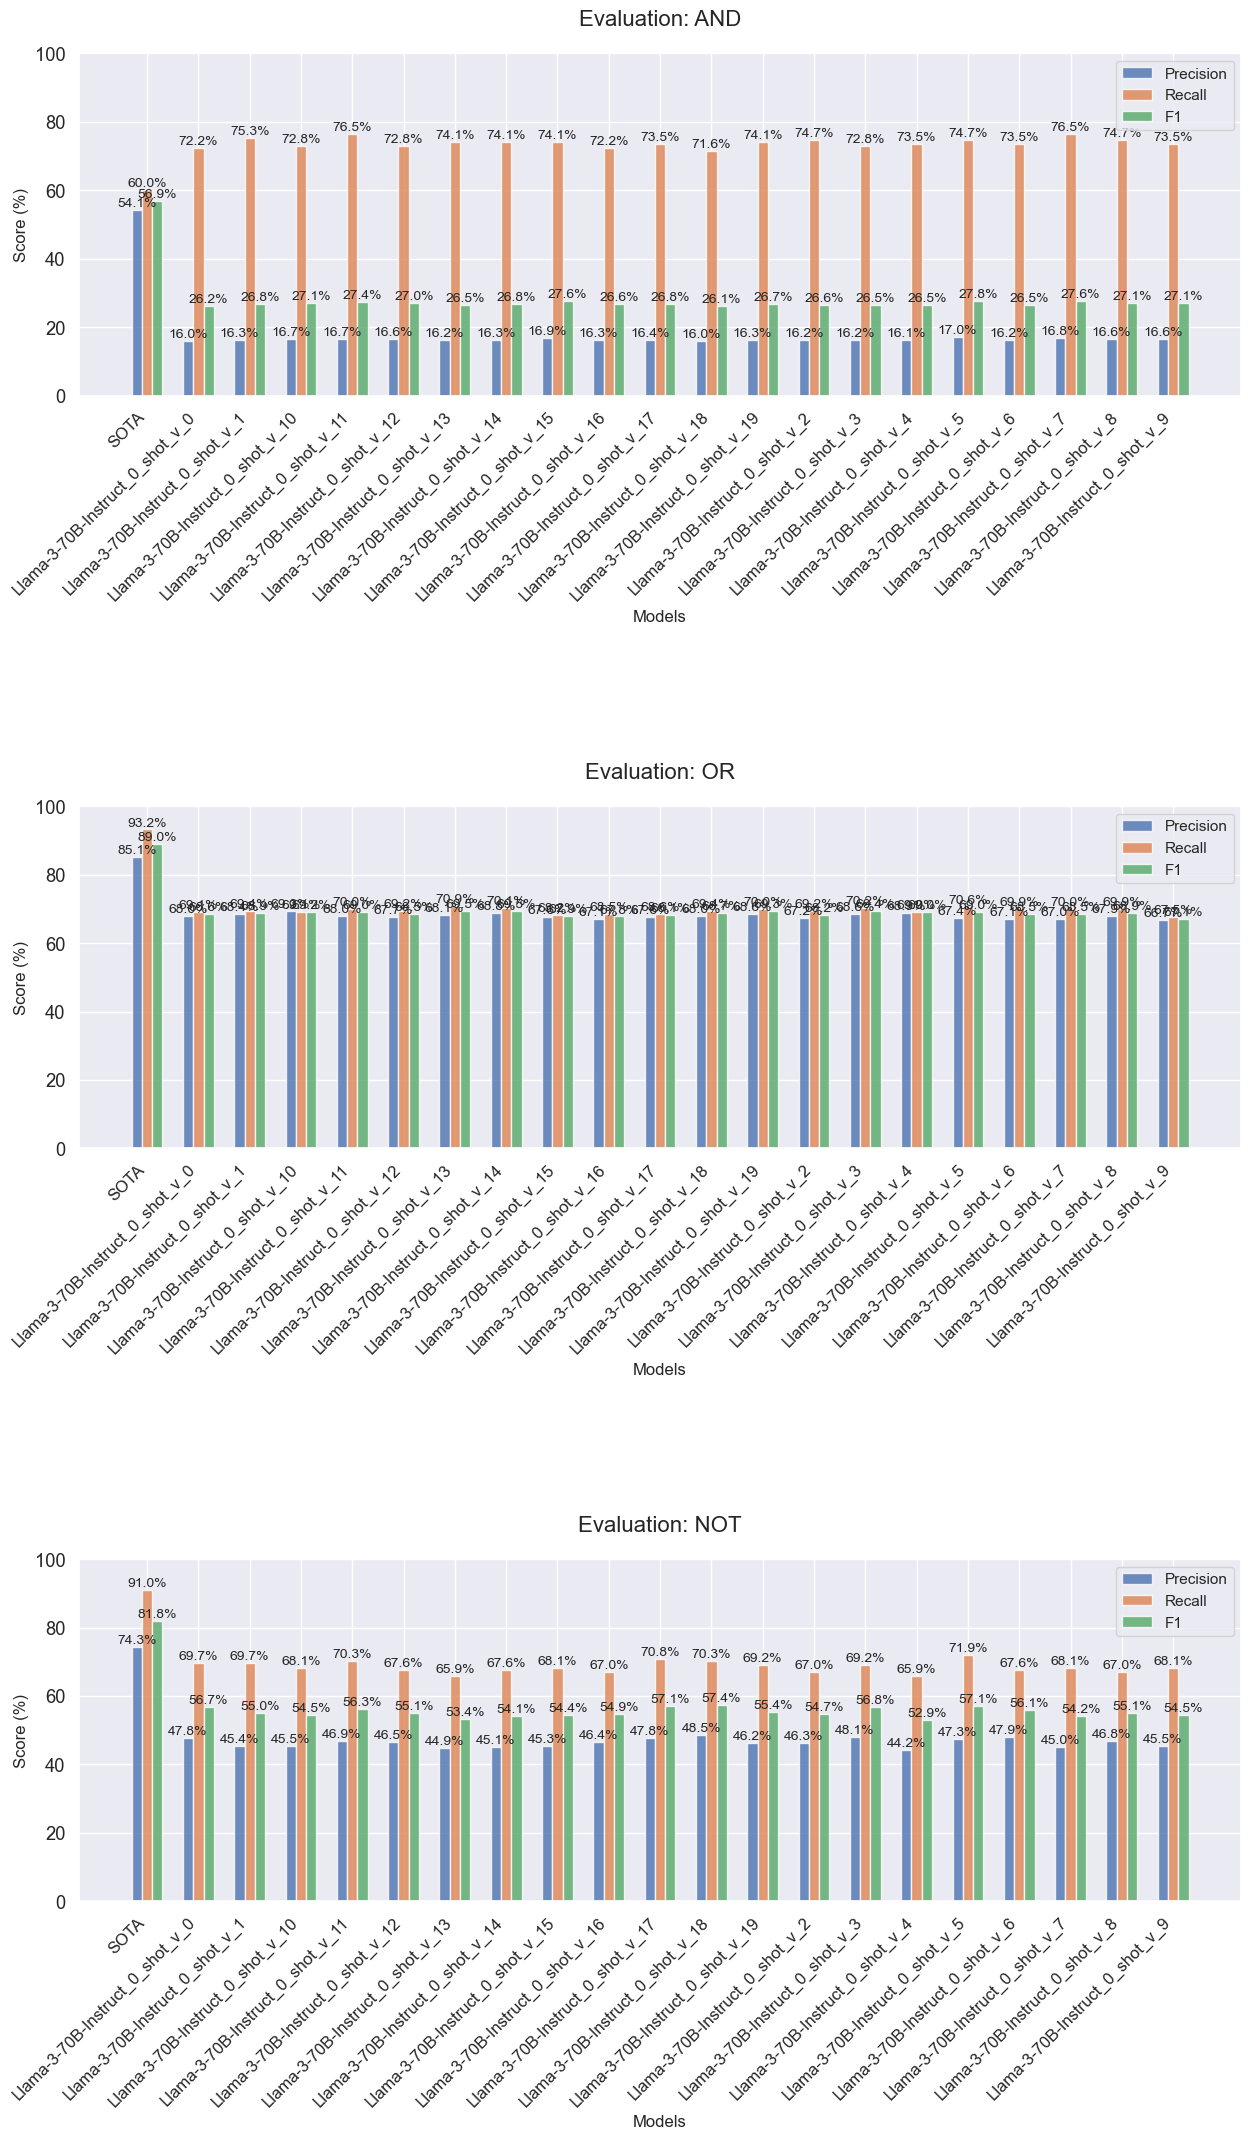

In [61]:
plot_metrics(all_metrics)

### Plot Anzahl Operators

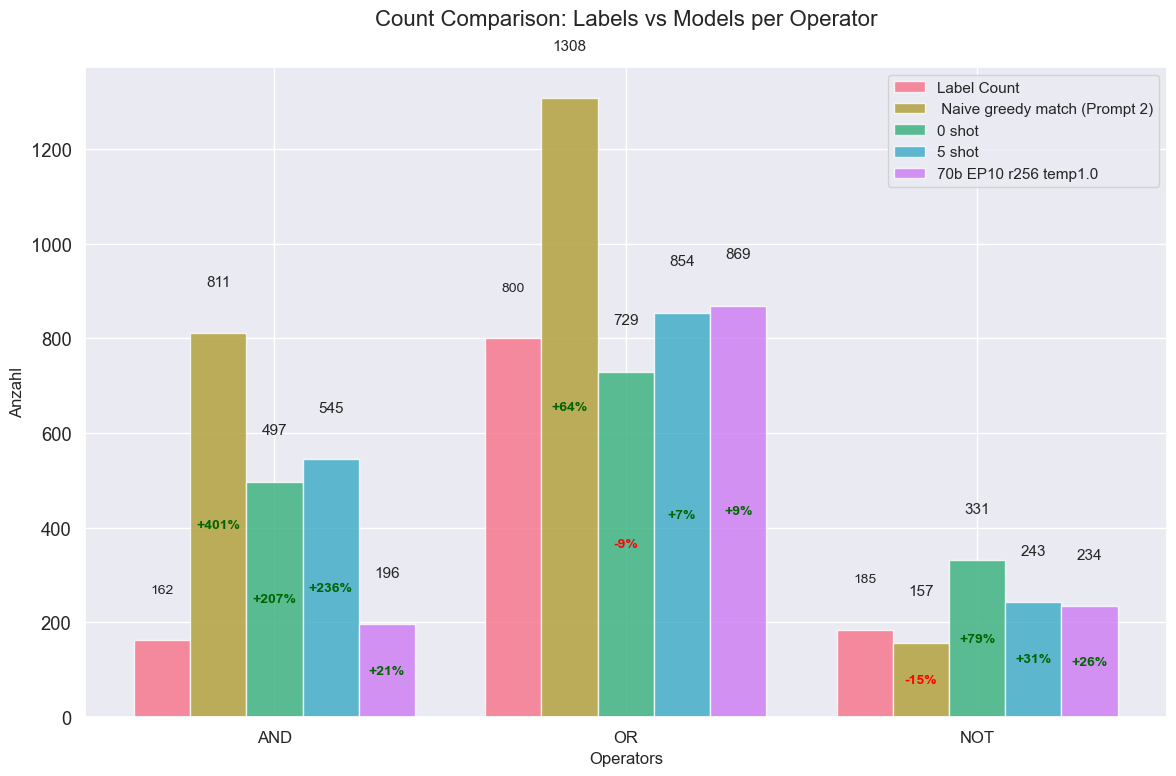

In [34]:
plot_count_comparison(all_metrics)

### Evaluiere n-shot Modelle

## Model vs SOTA


In [35]:
print(models)

model_to_plot = models[len(models)-2] # len(models)-1
model_name = model_to_plot
model_to_plot

[' Naive greedy match (Prompt 2)', '0_shot', '5_shot', '70b_EP10_r256_temp1.0']


'5_shot'

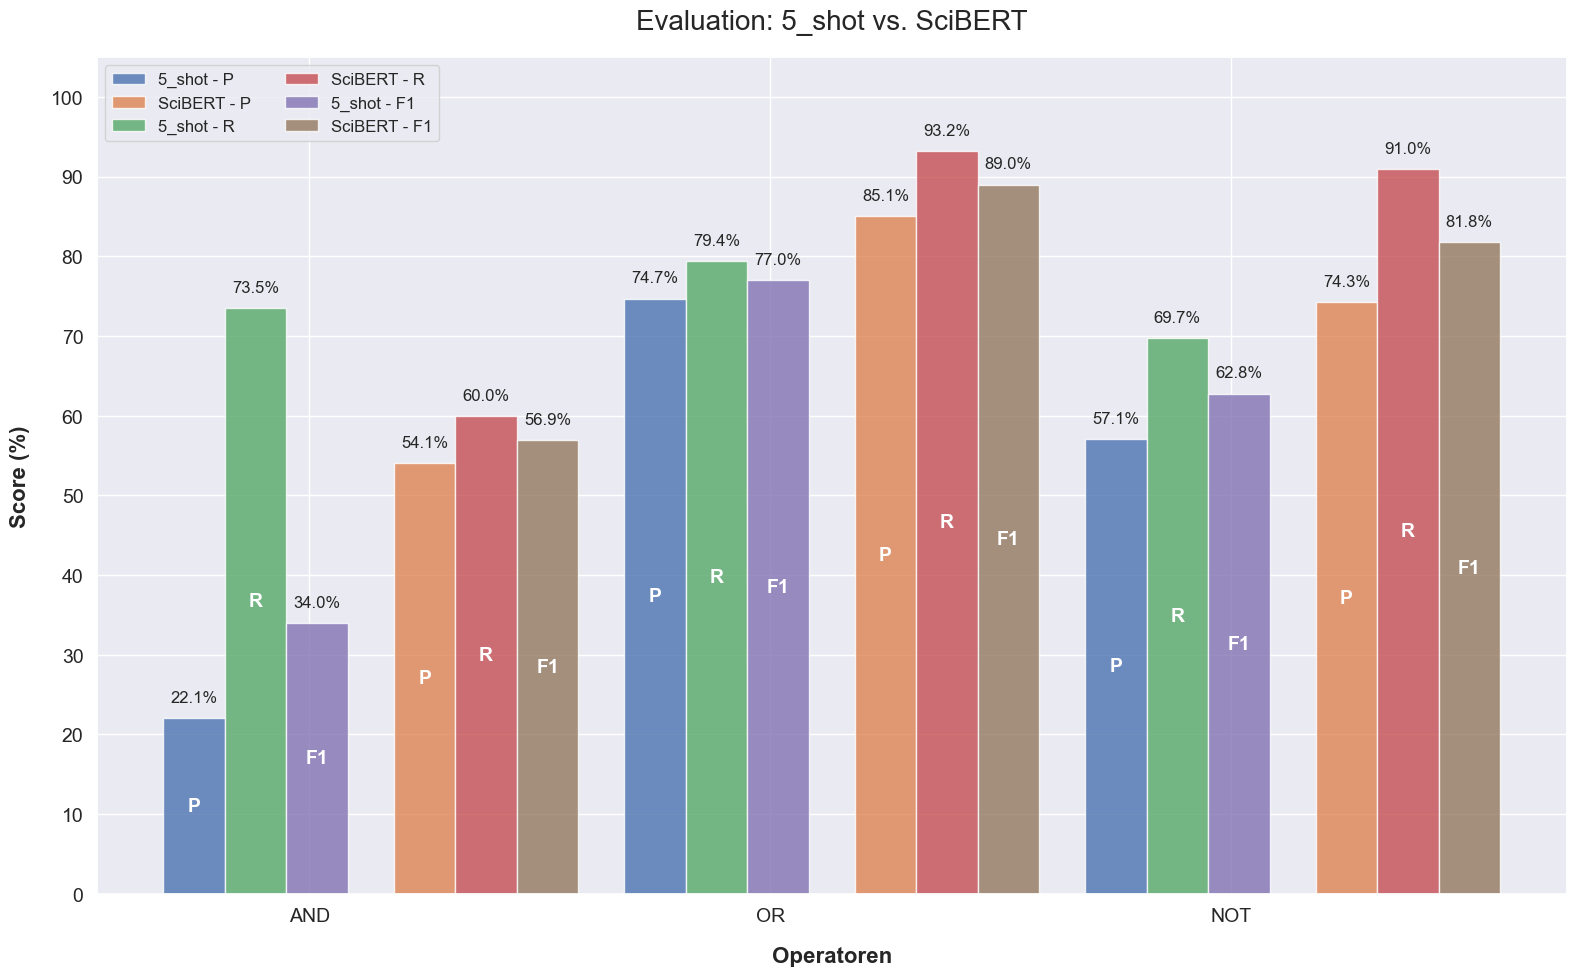

In [37]:
model_metrics = all_metrics[model_to_plot]


sota_metrics = {
    'SciBERT': {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0},
        'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
    },
    'R-BERT + SciBERT': {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2},
        'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
    }
}

operators = ['AND', 'OR', 'NOT']
metrics_to_plot = ['precision', 'recall', 'f1']
metric_labels = {'precision': 'P', 'recall': 'R', 'f1': 'F1'}

fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(operators))
bar_width = 0.4
opacity = 0.8
gap = 0.1

for i, metric in enumerate(metrics_to_plot):
    model_values = [model_metrics[op][metric] for op in operators]
    sota_values = [sota_metrics['SciBERT'][op][metric] for op in operators]

    ax.bar(x - bar_width/2 - gap/2 + i*bar_width/3, model_values, bar_width/3, alpha=opacity, label=f'{model_name.split("-Instruct")[0]} - {metric_labels[metric]}')
    ax.bar(x + bar_width/2 + gap/2 + i*bar_width/3, sota_values, bar_width/3, alpha=opacity, label=f'SciBERT - {metric_labels[metric]}')

    for j, (model_value, sota_value) in enumerate(zip(model_values, sota_values)):
        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value + 2, f'{model_value:.1f}%', ha='center', fontsize=12)
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value + 2, f'{sota_value:.1f}%', ha='center', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(operators, fontsize=14)
ax.set_xlabel('Operatoren', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='y', labelsize=14, width=2)
ax.yaxis.set_tick_params(labelsize=14)
ax.set_title(f'Evaluation: {model_name} vs. SciBERT', fontsize=20, pad=20)
ax.legend(fontsize=12, ncol=2, loc='upper left')
ax.grid(True)

plt.tight_layout()
#plt.savefig(f"pics/{model_to_plot}_vs_sota__{versuch_name}.png")
plt.show()

#### AND OR NOT Einzeln EVALUATION LATEX

In [38]:
and_or_not_to_latex(all_metrics, versuch_name)

'\\begin{table}[h]\n\\centering\n\\begin{tabular}{lccccccccc}\n\\toprule\nModel & \\multicolumn{3}{c}{AND} & \\multicolumn{3}{c}{OR} & \\multicolumn{3}{c}{NOT} \\\\\n\\cmidrule(lr){2-4} \\cmidrule(lr){5-7} \\cmidrule(lr){8-10} \n & P & R & F & P & R & F & P & R & F \\\\\n\\midrule\nSciBERT (SOTA) & 54.1 & 60.0 & 56.9 & 85.1 & \\textbf{93.2} & 89.0 & 74.3 & \\textbf{91.0} & \\textbf{81.8} \\\\\nR-BERT + SciBERT & 53.8 & 53.8 & 53.8 & \\textbf{88.4} & 92.2 & \\textbf{90.2} & \\textbf{74.5} & 88.7 & 81.0 \\\\\n Naive greedy match (Prompt 2) & 17.5 & \\textbf{86.4} & 29.1 & 54.3 & 87.9 & 67.1 & 61.9 & 51.9 & 56.5 \\\\\n0-shot & 20.9 & 63.0 & 31.4 & 69.9 & 63.7 & 66.7 & 37.8 & 62.2 & 47.0 \\\\\n5-shot & 22.1 & 73.5 & 34.0 & 74.7 & 79.4 & 77.0 & 57.1 & 69.7 & 62.8 \\\\\n70b-EP10-r256-temp1.0 & \\textbf{59.9} & 71.0 & \\textbf{65.0} & 84.8 & 91.8 & 88.1 & 73.0 & 90.8 & 81.0 \\\\\n\\bottomrule\n\\end{tabular}\n\\caption{Model Performance Metrics}\n\\label{tab:model_metrics}\n\\end{table}\n'